In [9]:
# -*- coding: utf-8 -*-
from pathlib import Path
import os
from xml import dom
import pandas as pd
import numpy as np
import keras
from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np
import cv2
from astropy.io import fits
from astropy.convolution import convolve, Box1DKernel
import statistics
import matplotlib.pyplot as plt
import joblib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec
import textwrap
import logging
import shutil

import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))
import src.features.build_features as bfs
import src.visualization.visualize as vsz


# Define relative paths to project and current directory.

current_dir =  Path(globals()['_dh'][0])
project_dir =  Path(globals()['_dh'][0]).parent

# Load desired model for prediction and class map activation

model = keras.models.load_model(os.path.join(project_dir, r'models\best_model_all_data.h5'))
dom_rf_model = joblib.load(os.path.join(project_dir, r'models\rf_best_model.joblib'))

# we define a gradCAM class for loading the model and generating the heatmap.

class GradCAM:
    def __init__(self, model, classIdx, layerName=None):
        # store the model, the class index used to measure the class
        # activation map, and the layer to be used when visualizing
        # the class activation map
        self.model = model
        self.classIdx = classIdx
        self.layerName = layerName
        # if the layer name is None, attempt to automatically find
        # the target output layer
        if self.layerName is None:
            self.layerName = self.find_target_layer()


    def find_target_layer(self):
        # attempt to find the final convolutional layer in the network
        # by looping over the layers of the network in reverse order
        for layer in reversed(self.model.layers):
            # check to see if the layer has a 3D output
            if len(layer.output_shape) == 3:
                return layer.name
        # otherwise, we could not find a 4D layer so the GradCAM
        # algorithm cannot be applied
        raise ValueError("Could not find 3D layer. Cannot apply GradCAM.")


    def compute_heatmap(self, flux, eps=1e-8):
        # construct our gradient model by supplying (1) the inputs
        # to our pre-trained model, (2) the output of the (presumably)
        # final 3D layer in the network, and (3) the output of the
        # softmax activations from the model
        gradModel = Model(
            inputs=[self.model.inputs],
            outputs=[self.model.get_layer(self.layerName).output,
                     self.model.output])

        # record operations for automatic differentiation
        with tf.GradientTape() as tape:
            # cast the flux tensor to a float-32 data type, pass the
            # flux through the gradient model, and grab the loss
            # associated with the specific class index
            inputs = tf.cast(flux, tf.float32)
            (convOutputs, predictions) = gradModel(inputs)
            loss = predictions[:, self.classIdx]
        # use automatic differentiation to compute the gradients
        grads = tape.gradient(loss, convOutputs)

        # compute the guided gradients
        castConvOutputs = tf.cast(convOutputs > 0, "float32")
        castGrads = tf.cast(grads > 0, "float32")
        guidedGrads = castConvOutputs * castGrads * grads
        # the convolution and guided gradients have a batch dimension
        # (which we don't need) so let's grab the volume itself and
        # discard the batch
        convOutputs = convOutputs[0]
        guidedGrads = guidedGrads[0]

        # compute the average of the gradient values, and using them
        # as weights, compute the ponderation of the filters with
        # respect to the weights
        weights = tf.reduce_mean(guidedGrads, axis=(0, 1))
        cam = tf.reduce_sum(tf.multiply(weights, convOutputs), axis=-1)

        # grab the spatial dimensions of the input image and resize
        # the output class activation map to match the input image
        # dimensions
        (w, h) = (flux.shape[2], flux.shape[1])
        heatmap = cv2.resize(cam.numpy(), (w, h))
        # normalize the heatmap such that all values lie in the range
        # [0, 1], scale the resulting values to the range [0, 255],
        # and then convert to an unsigned 8-bit integer
        numer = heatmap - np.min(heatmap)
        denom = (heatmap.max() - heatmap.min()) + eps
        heatmap = numer / denom
        heatmap = (heatmap * 255).astype("uint8")
        # return the resulting heatmap to the calling function
        return heatmap

# Load ohe dictionary used for training, currently done manually. 

ohe_dict = {'WDA': np.array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
            'WDZ': np.array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
            'WDB': np.array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
            'WDO': np.array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
            'WD+MS': np.array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
            'WD': np.array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
            'sdX': np.array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
            'WDH': np.array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
            'WDELM': np.array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
            'WDC': np.array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
            'CV': np.array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
            'WDQ': np.array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])}

star_class = vsz.sort_ohe(ohe_dict)

def extraction(fits_file):
    hdu  = fits.open(fits_file)
    data = hdu['COADD'].data
    w = 10**data['loglam']
    f = data['flux']*1e-17
    return w,f

def load_spectrum_data(file_path: str):
    if file_path.endswith('fits'):
        wavelength, flux = extraction(file_path)
    elif file_path.endswith('.dat'):
        sed = np.loadtxt(file_path, unpack = True)
        wavelength = sed[0,:]
        flux = sed[1,:]
    else:
        print("what format is that?")
        return None
    
    return wavelength, flux

def nan_helper(y):
    """Helper to handle indices and logical indices of NaNs.

    Input:
        - y, 1d numpy array with possible NaNs
    Output:
        - nans, logical indices of NaNs
        - index, a function, with signature indices= index(logical_indices),
          to convert logical indices of NaNs to 'equivalent' indices
    Example:
        >>> # linear interpolation of NaNs
        >>> nans, x= nan_helper(y)
        >>> y[nans]= np.interp(x(nans), x(~nans), y[~nans])
    """

    return np.isnan(y), lambda z: z.nonzero()[0]

base_wavelenght, _ = load_spectrum_data(os.path.join(project_dir, 'calibration_dat_file.dat'))
base_wavelenght = base_wavelenght[298:-600] # this is the wavelenght axis the model was trained on.

def png_report_generator(flux, predicted_class, dom_pred, filepath, save_path, extra):
    fig = plt.figure(figsize=(20,13)) 

    gs = GridSpec(2, 3, figure=fig)
    cam_wda = GradCAM(model, int(predicted_class))
    params = {'mathtext.default': 'regular' }          
    plt.rcParams.update(params)

    # spectrum, heatmap, activation ant text axes

    spax = fig.add_subplot(gs[0, 0:2])
    hmax = fig.add_subplot(gs[1, 0:2])
    acax = fig.add_subplot(gs[0, 2])
    tax = fig.add_subplot(gs[1, 2])

    # Spectrum plot

    spax.set_title('Flux plot (normalized)')
    spax.plot(base_wavelenght, flux, color='black', linewidth=0.5)
    spax.get_tightbbox(renderer=fig.canvas.get_renderer())
    spax.set_ylabel('$F_\lambda$ (Normalized)', fontsize=12)

    # Heatmap Plot

    heatmap = cam_wda.compute_heatmap(flux.reshape(1,-1,1))
    hmax.set_title('Class Activation Map for predicted class.')
    sc = hmax.scatter(base_wavelenght, flux, c=heatmap, s=6, cmap = 'inferno')
    hmax.set_ylabel('$F_\lambda$ (Normalized)', fontsize=12)
    cbaxes = inset_axes(hmax, width="15%", height="3%", loc=1) 
    fig.colorbar(sc, cax=cbaxes, orientation='horizontal')

    ### Activation plot

    acax.set_title('Network output')
    my_range=list(range(1,13))

    preds = model.predict(flux.reshape(1,-1,1)).reshape((12,))

    ### Draw predictions 
    acax.hlines(y=star_class, xmin=0, xmax=preds, color='#DDA0DD', alpha=0.2, linewidth=5)
    acax.set_xlabel('Class Score', fontsize=12, color = '#333F4B')
    acax.set_ylabel('')

    # add little dots
    acax.plot(preds, star_class, "o", markersize=5, color='#A020F0', alpha=0.6)

    # add label for top 3 predictions

    try:
        for value in sorted(preds, reverse=True)[:3]:
            acax.text(value - 0.02, int(np.where(preds == value)[0][0]) - 0.5, "{:.2f}".format(value), fontsize=9, color = '#333F4B')
    except:
        pass

    acax.text(-0.1, 11.5, 'Class', fontsize=12, color = '#333F4B')

    # change the style of the axis spines
    acax.spines['top'].set_visible(False)
    acax.spines['right'].set_visible(False)
    acax.spines['left'].set_bounds((0, len(star_class)-1))
    acax.set_xlim(-0.01,max(preds)+0.01)

    # add some space between the axis and the plot
    acax.spines['left'].set_position(('outward', 8))
    acax.spines['bottom'].set_position(('outward', 5))

    ### Text box axis

    value = """The domain detector thinks this spectrum {} a white dwarf. \nThe neural network predicts this is most likely a {} sub-type, with a score of {:.2f}. \nThe actual label for the object is {}.  \nfilepath={}
    """.format('is' if bool(dom_pred) else "isn't", star_class[int(np.where(preds == max(preds))[0])], max(preds), extra, str(filepath))

    # Wrap this text.
    wrapper = textwrap.TextWrapper(width=55, replace_whitespace=False)
    
    word_list = []  
    for paragraph in value.split('\n'):
        word_list += wrapper.wrap(text=paragraph) + [' ']
    # Print each line.
    Delta = 0.05
    for (i, element) in enumerate(word_list):
        tax.text(-0.05, 0.9 - i * Delta, element , fontsize=13 ,  transform=tax.transAxes)

    tax.set_axis_off()

    spax.autoscale(tight=True)
    hmax.autoscale(tight=True)

    plt.savefig(os.path.join(save_path, filepath[:-4].replace('.','_')), bbox_inches='tight')
    plt.clf()
    plt.close(fig)

c:\Users\jotab\anaconda3\envs\astro\lib\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.1.1 when using version 1.1.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\jotab\anaconda3\envs\astro\lib\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator RandomForestClassifier from version 1.1.1 when using version 1.1.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [15]:
save_path = r'D:\ds_sets_results\test'
sdss_data_path = os.path.join(project_dir, r'data\raw\sdss_dat_files')

### Loading numpy matrices for analysis

test_label_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-class-activation-map\test_label_matrix.npy'))
valid_label_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-class-activation-map\valid_label_matrix.npy'))
test_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-class-activation-map\test_spectrum_matrix.npy'))
valid_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-class-activation-map\valid_spectrum_matrix.npy'))

## Loafing csv files from sets 

valid_csv_path = os.path.join(project_dir, r'notebooks\1.0-jrb-class-activation-map\valid_set.csv')
valid_set = pd.read_csv(valid_csv_path)
test_csv_path = os.path.join(project_dir, r'notebooks\1.0-jrb-class-activation-map\test_set.csv')
test_set = pd.read_csv(test_csv_path)
print(valid_set, valid_set)

                                               filename classID
0     wd\SDSSJ122257.58+300242.6_15249-59265-0059_46...     WDA
1     wd\SDSSJ012606.08+144045.9_15010-59199-0313_44...     WDA
2     wd\SDSSJ090803.30+513632.7_15174-59232-0014_43...     WDZ
3     wd\SDSSJ015221.11-003037.7_15013-59165-0159_43...     WDA
4     wd\SDSSJ084824.88+020918.5_15146-59206-0321_45...     WDA
...                                                 ...     ...
1118  wd\SDSSJ083628.20+354649.6_15062-59227-0336_45...     WDA
1119  wd\SDSSJ063256.89+171629.5_15229-59303-0400_45...     WDA
1120  wd\SDSSJ164122.52+393649.2_15309-59312-0293_51...     WDA
1121  wd\SDSSJ075645.52+272747.8_15021-59165-0078_45...     WDA
1122  wd\SDSSJ080051.54+223558.4_15051-59204-0252_45...     WDA

[1123 rows x 2 columns]                                                filename classID
0     wd\SDSSJ122257.58+300242.6_15249-59265-0059_46...     WDA
1     wd\SDSSJ012606.08+144045.9_15010-59199-0313_44...     WDA
2     wd\SDSSJ0

In [16]:
#### filepath iteration ###
results_df = pd.DataFrame(columns=['filename', 'label' 'preds'])
counter = 0
scanned_counter = 0



for index, row in test_set.iterrows():
    # print(row['filename'], row['classID'])
    file = row['filename']
    scanned_counter += 1
    if file.endswith('.dat'):
        w, f = load_spectrum_data(os.path.join(r'C:\Users\jotab\Documents\Github\sdss_repo\data\raw\sdss_dat_files', file))
        # Interpolation

        if (np.isnan(f).any()):
            nans, x= nan_helper(f)
            f[nans] = np.interp(x(nans), x(~nans), f[~nans])
        if (np.isnan(w).any()):
            nans, x= nan_helper(w)
            w[nans] = np.interp(x(nans), x(~nans), w[~nans])
        if(np.isnan(w).all() or np.isnan(f).all()):
            # logger.info('Foun all nan file {}'.format(file))
            continue

        flux = np.interp(base_wavelenght, w, f)
        # normalization
        norm_magnitud = statistics.mean(flux[2050:2100])

        if statistics.mean(flux[2050:2100]) == 0:
            # logger.info('Foun all 0 file {}'.format(file))
            continue
        else:
            flux = np.divide(flux, statistics.mean(flux[2050:2100]))

        # model prediction
        dom_pred = dom_rf_model.predict(flux.reshape(1, -1) )
        prediction = model.predict(flux.reshape(1,-1,1))
        preds = model.predict(flux.reshape(1,-1,1)).reshape((12,))
        predicted_class_str = star_class[int(np.where(preds == max(preds))[0])]

        # decide if generate a full report or not.

        if ((row['classID'] == 'WD')):
            predicted_class = prediction.argmax(1)
            try:
                os.mkdir(os.path.join(save_path, file.split('\\')[0]))
            except:
                pass
            png_report_generator(flux, predicted_class, dom_pred, filepath=os.path.join(file), save_path=save_path, extra=row['classID'])
            counter += 1
            # logger.info('Foun and interesting one! file {}, type {}, object number {}'.format(file, predicted_class_str, counter))

            results_df = results_df.append({'filename' : file, 'label' : row['classID'],'preds' : predicted_class_str}, ignore_index=True)
            shutil.copyfile(src = os.path.join(r'C:\Users\jotab\Documents\Github\sdss_repo\data\raw\sdss_dat_files', file), dst = os.path.join(save_path, file))

results_df.to_csv(os.path.join(save_path, 'results.csv') , index=False)
print('scanned {} elements in total'.format(scanned_counter))

1/1 [==============================] - ETA: 0s

C:\Users\jotab\AppData\Local\Temp\ipykernel_1720\503619284.py:54: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({'filename' : file, 'label' : row['classID'],'pred' : predicted_class_str}, ignore_index=True)


1/1 [==============================] - 0s 17ms/step


C:\Users\jotab\AppData\Local\Temp\ipykernel_1720\503619284.py:54: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({'filename' : file, 'label' : row['classID'],'pred' : predicted_class_str}, ignore_index=True)


1/1 [==============================] - 0s 19ms/step


...

1/1 [==============================] - 0s 21ms/step


C:\Users\jotab\AppData\Local\Temp\ipykernel_1720\503619284.py:54: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({'filename' : file, 'label' : row['classID'],'pred' : predicted_class_str}, ignore_index=True)


1/1 [==============================] - 0s 20ms/step


C:\Users\jotab\AppData\Local\Temp\ipykernel_1720\503619284.py:54: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({'filename' : file, 'label' : row['classID'],'pred' : predicted_class_str}, ignore_index=True)


1/1 [==============================] - 0s 21ms/step
scanned 1124 elements in total


# Confussion matrices

89/89 [==============================] - 3s 28ms/step


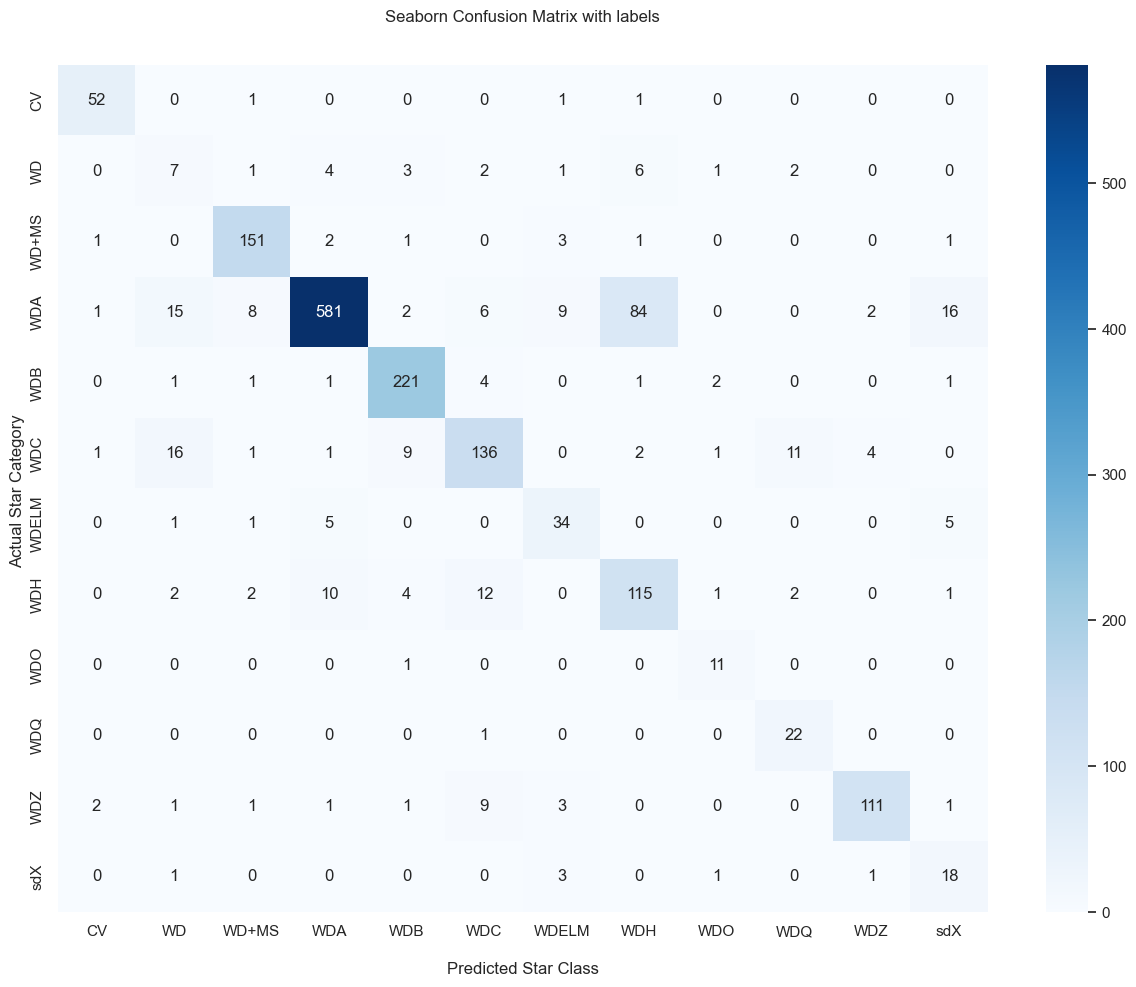

In [12]:
from sklearn.metrics import confusion_matrix

cf_model = r'C:\Users\jotab\Documents\Github\sdss_repo\models\best_model_all_data.h5'
model_cf = keras.models.load_model(cf_model)
sample_output = model_cf.predict(test_spectrum_matrix, batch_size=20)

predict_class = np.argmax(sample_output, axis=1)
actual_class = np.argmax(test_label_matrix, axis=1)
cf_matrix = confusion_matrix(actual_class, predict_class)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc = {'figure.figsize':(15,11)})
ax = sns.heatmap(cf_matrix, annot=True, fmt='.3g', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Star Class')
ax.set_ylabel('Actual Star Category ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(star_class)
ax.yaxis.set_ticklabels(star_class)

## Display the visualization of the Confusion Matrix.
plt.show()

89/89 [==============================] - 3s 29ms/step


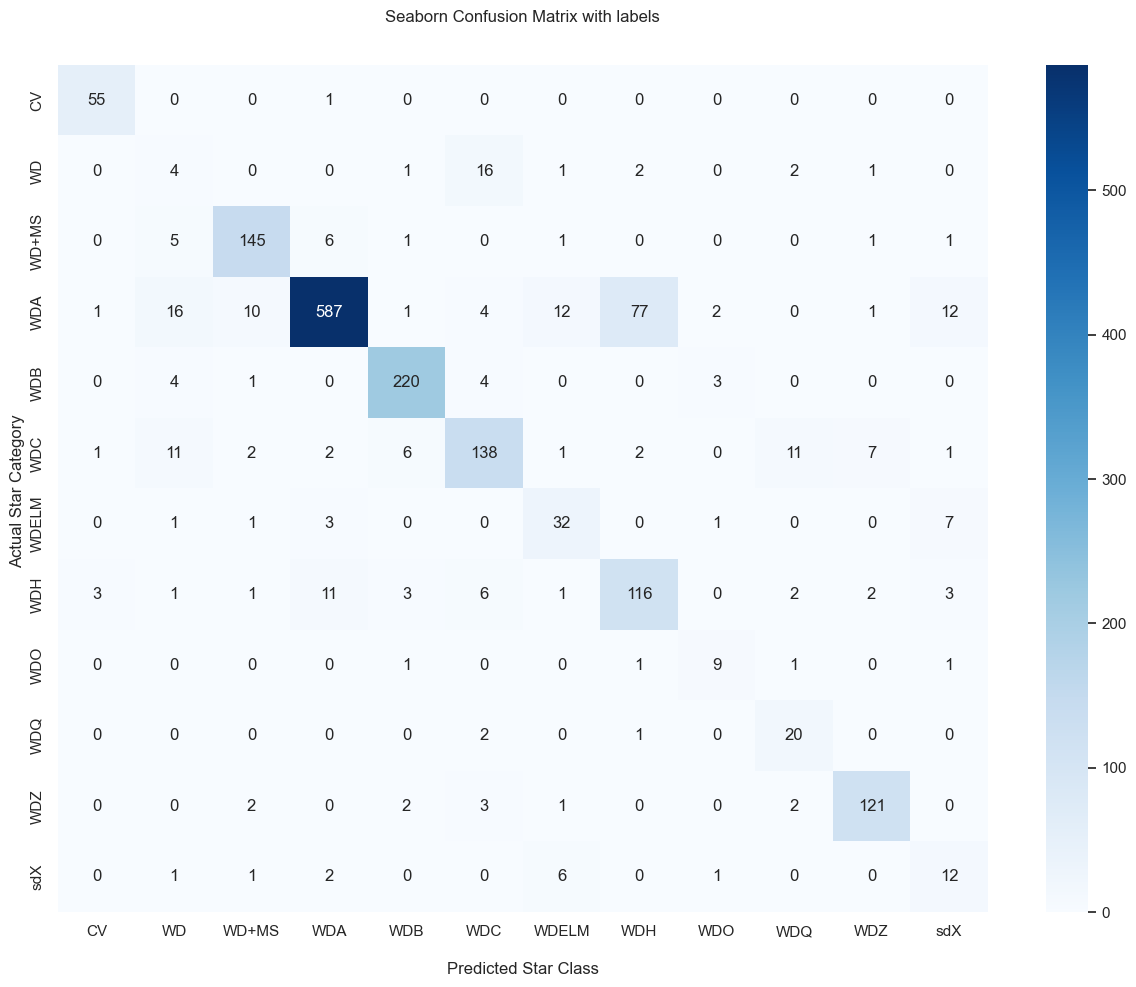

In [13]:
from sklearn.metrics import confusion_matrix

cf_model = r'C:\Users\jotab\Documents\Github\sdss_repo\models\best_model_all_data.h5'
model_cf = keras.models.load_model(cf_model)
sample_output = model_cf.predict(valid_spectrum_matrix, batch_size=20)

predict_class = np.argmax(sample_output, axis=1)
actual_class = np.argmax(valid_label_matrix, axis=1)
cf_matrix = confusion_matrix(actual_class, predict_class)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc = {'figure.figsize':(15,11)})
ax = sns.heatmap(cf_matrix, annot=True, fmt='.3g', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Star Class')
ax.set_ylabel('Actual Star Category ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(star_class)
ax.yaxis.set_ticklabels(star_class)

## Display the visualization of the Confusion Matrix.
plt.show()